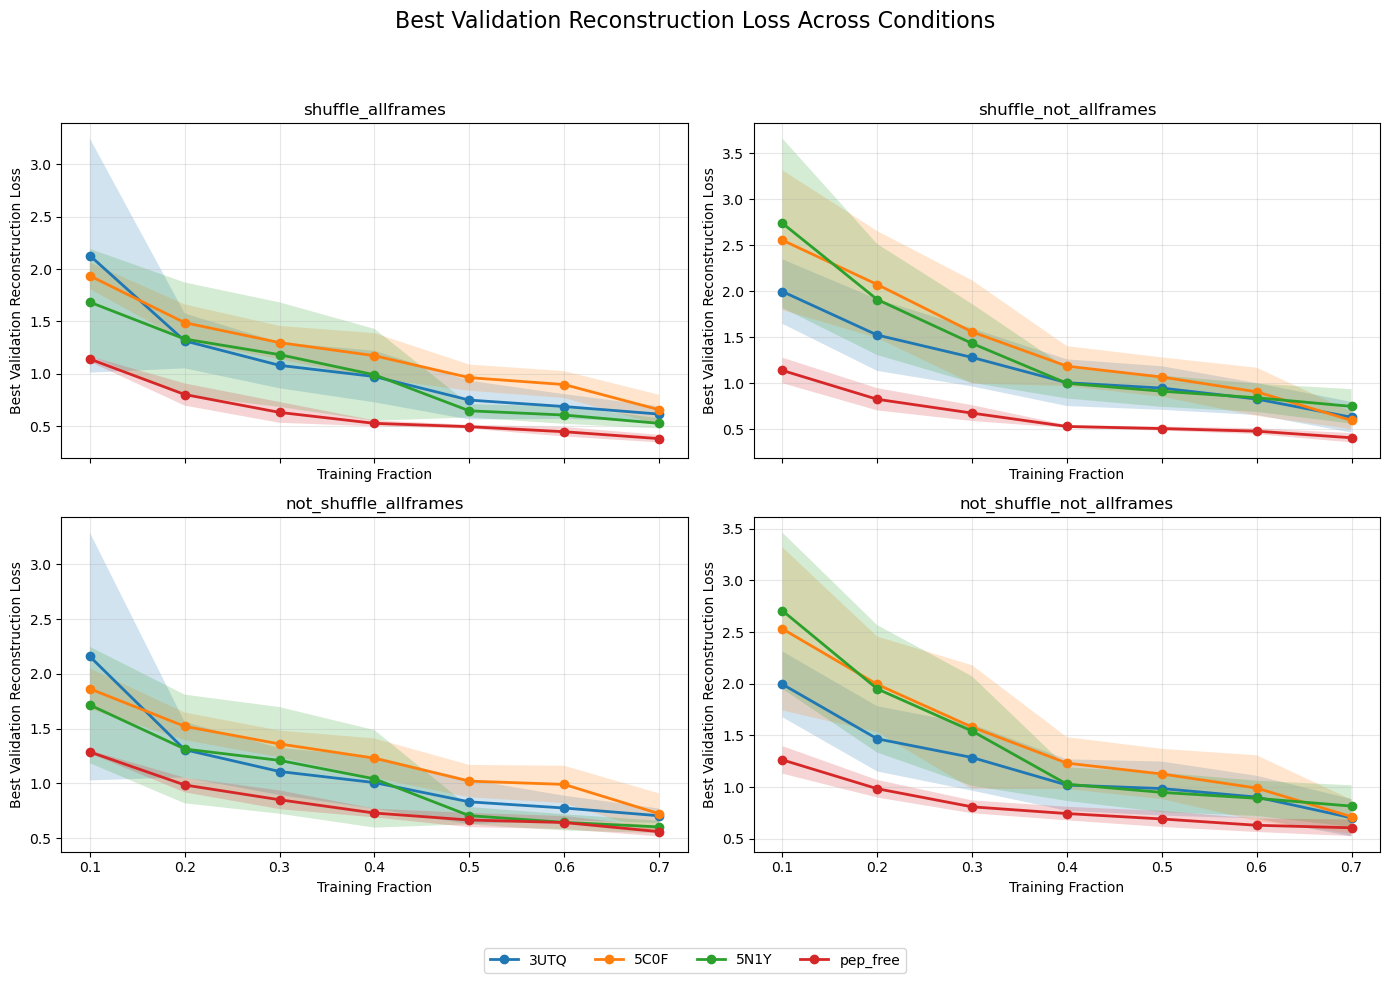

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch

fractions = [10, 20, 30, 40, 50, 60, 70]
proteins = ["3UTQ", "5C0F", "5N1Y", "pep_free"]
replicas = [0, 1, 2]

conditions = [
    "shuffle_allframes",
    "shuffle_not_allframes",
    "not_shuffle_allframes",
    "not_shuffle_not_allframes"
]

base_root = "../"
fractions_float = [f / 100 for f in fractions]

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=False)
axes = axes.flatten()

for ax, condition in zip(axes, conditions):

    protein_means = {}
    protein_stds = {}

    for protein in proteins:
        rep_recon_all = []

        for rep in replicas:
            rep_dir = os.path.join(
                base_root,
                condition,
                protein,
                f"{protein}_rep_{rep}"
            )

            rep_recon = []

            for frac in fractions:
                ckpt_path = os.path.join(
                    rep_dir,
                    f"fraction_{frac}",
                    "best.ckpt"
                )

                if not os.path.exists(ckpt_path):
                    print(f"[WARNING] Missing checkpoint: {ckpt_path}")
                    rep_recon.append(np.nan)
                    continue

                ckpt = torch.load(ckpt_path, map_location="cpu")
                rep_recon.append(ckpt["best_val_recon"])

            rep_recon_all.append(rep_recon)

        rep_recon_all = np.array(rep_recon_all, dtype=float)

        protein_means[protein] = np.nanmean(rep_recon_all, axis=0)
        protein_stds[protein] = np.nanstd(rep_recon_all, axis=0)

    for protein in proteins:
        mean_vals = protein_means[protein]
        std_vals = protein_stds[protein]

        ax.plot(
            fractions_float,
            mean_vals,
            marker="o",
            linewidth=2,
            label=protein
        )

        ax.fill_between(
            fractions_float,
            mean_vals - std_vals,
            mean_vals + std_vals,
            alpha=0.2
        )

    ax.set_title(condition)
    ax.set_xlabel("Training Fraction")
    ax.set_ylabel("Best Validation Reconstruction Loss")
    ax.grid(True, alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=4,
    frameon=True,
    bbox_to_anchor=(0.5, 0.01)
)
fig.suptitle(
    "Best Validation Reconstruction Loss Across Conditions",
    fontsize=16,
    y=0.98
)

plt.tight_layout(rect=[0, 0.08, 1, 0.94])

plt.savefig(
    "BestValRecon_all_conditions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

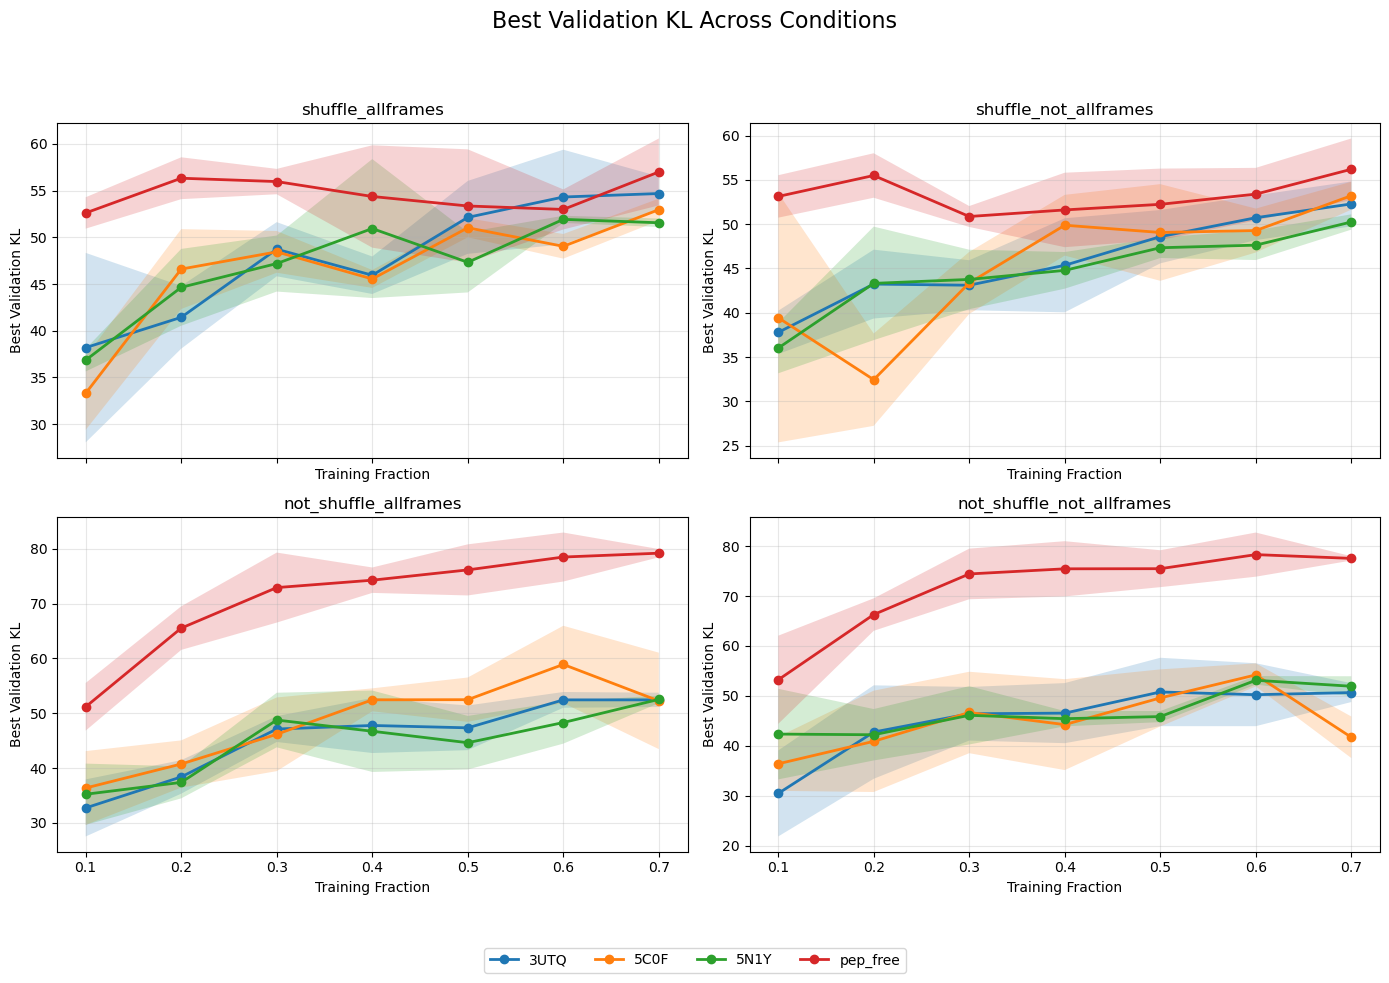

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch

fractions = [10, 20, 30, 40, 50, 60, 70]
proteins = ["3UTQ", "5C0F", "5N1Y", "pep_free"]
replicas = [0, 1, 2]

conditions = [
    "shuffle_allframes",
    "shuffle_not_allframes",
    "not_shuffle_allframes",
    "not_shuffle_not_allframes"
]

base_root = "../"
fractions_float = [f / 100 for f in fractions]

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=False)
axes = axes.flatten()

for ax, condition in zip(axes, conditions):

    protein_means = {}
    protein_stds = {}

    for protein in proteins:

        rep_kl_all = []

        for rep in replicas:

            rep_dir = os.path.join(
                base_root,
                condition,
                protein,
                f"{protein}_rep_{rep}"
            )

            rep_kl = []

            for frac in fractions:

                ckpt_path = os.path.join(
                    rep_dir,
                    f"fraction_{frac}",
                    "best.ckpt"
                )

                if not os.path.exists(ckpt_path):
                    print(f"[WARNING] Missing checkpoint: {ckpt_path}")
                    rep_kl.append(np.nan)
                    continue

                ckpt = torch.load(ckpt_path, map_location="cpu")
                rep_kl.append(ckpt["best_val_kl"])

            rep_kl_all.append(rep_kl)

        rep_kl_all = np.array(rep_kl_all, dtype=float)

        protein_means[protein] = np.nanmean(rep_kl_all, axis=0)
        protein_stds[protein] = np.nanstd(rep_kl_all, axis=0)

    for protein in proteins:

        mean_vals = protein_means[protein]
        std_vals = protein_stds[protein]

        ax.plot(
            fractions_float,
            mean_vals,
            marker="o",
            linewidth=2,
            label=protein
        )

        ax.fill_between(
            fractions_float,
            mean_vals - std_vals,
            mean_vals + std_vals,
            alpha=0.2
        )

    ax.set_title(condition)
    ax.set_xlabel("Training Fraction")
    ax.set_ylabel("Best Validation KL")
    ax.grid(True, alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=4,
    frameon=True,
    bbox_to_anchor=(0.5, 0.01)
)

fig.suptitle(
    "Best Validation KL Across Conditions",
    fontsize=16,
    y=0.98
)

plt.tight_layout(rect=[0, 0.08, 1, 0.94])

plt.savefig(
    "BestValKL_all_conditions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Equal

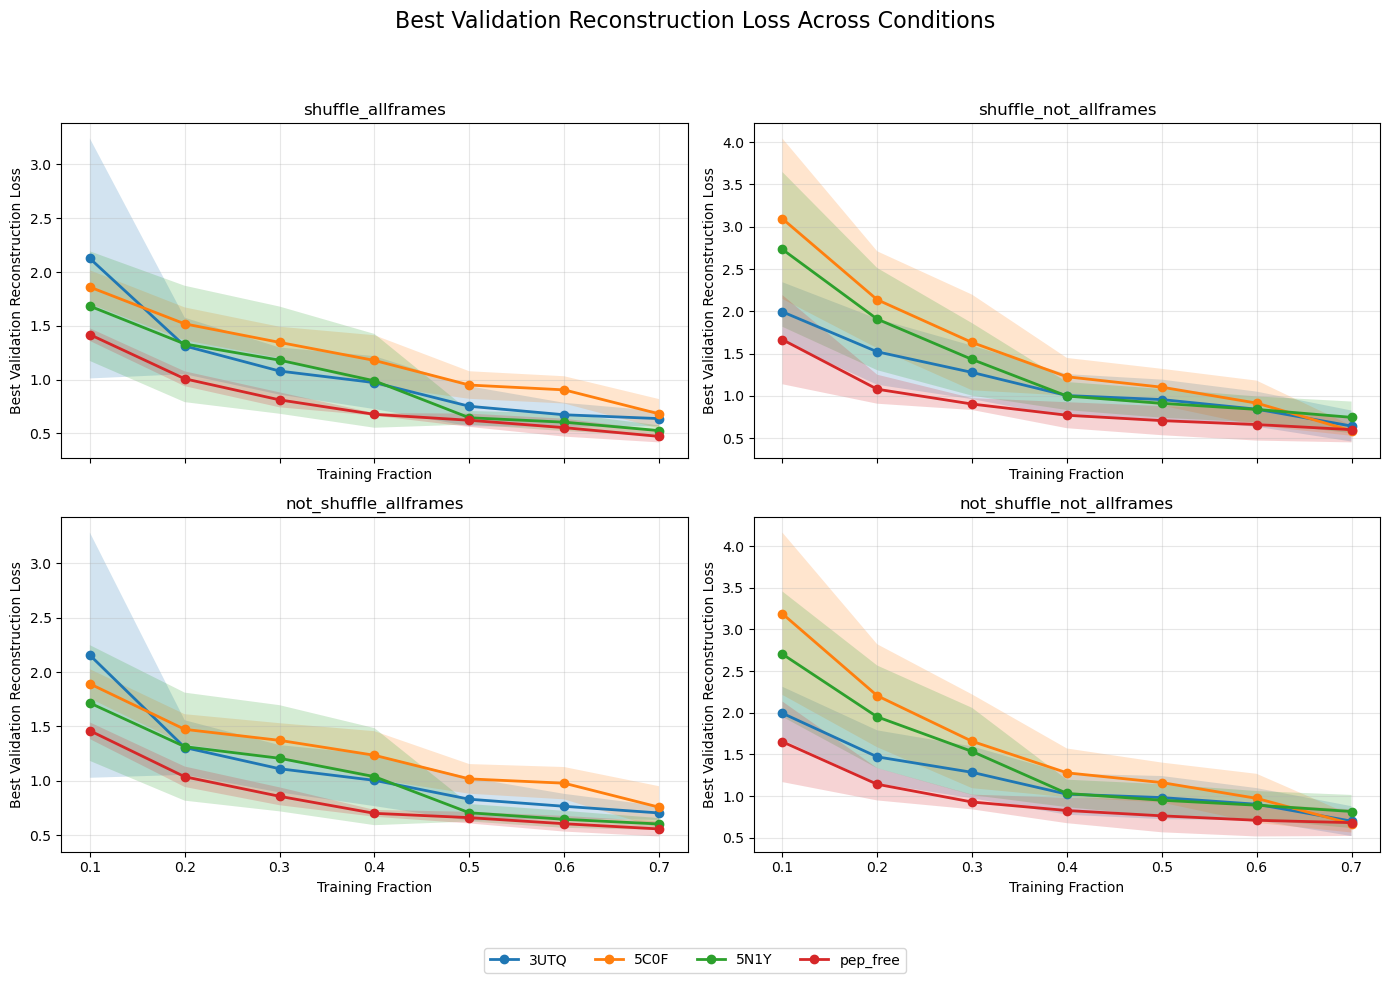

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch

fractions = [10, 20, 30, 40, 50, 60, 70]
proteins = ["3UTQ", "5C0F", "5N1Y", "pep_free"]
replicas = [0, 1, 2]

conditions = [
    "shuffle_allframes",
    "shuffle_not_allframes",
    "not_shuffle_allframes",
    "not_shuffle_not_allframes"
]

base_root = "../Equal_frames"
fractions_float = [f / 100 for f in fractions]

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=False)
axes = axes.flatten()

for ax, condition in zip(axes, conditions):

    protein_means = {}
    protein_stds = {}

    for protein in proteins:
        rep_recon_all = []

        for rep in replicas:
            rep_dir = os.path.join(
                base_root,
                condition,
                protein,
                f"{protein}_rep_{rep}"
            )

            rep_recon = []

            for frac in fractions:
                ckpt_path = os.path.join(
                    rep_dir,
                    f"fraction_{frac}",
                    "best.ckpt"
                )

                if not os.path.exists(ckpt_path):
                    print(f"[WARNING] Missing checkpoint: {ckpt_path}")
                    rep_recon.append(np.nan)
                    continue

                ckpt = torch.load(ckpt_path, map_location="cpu")
                rep_recon.append(ckpt["best_val_recon"])

            rep_recon_all.append(rep_recon)

        rep_recon_all = np.array(rep_recon_all, dtype=float)

        protein_means[protein] = np.nanmean(rep_recon_all, axis=0)
        protein_stds[protein] = np.nanstd(rep_recon_all, axis=0)

    for protein in proteins:
        mean_vals = protein_means[protein]
        std_vals = protein_stds[protein]

        ax.plot(
            fractions_float,
            mean_vals,
            marker="o",
            linewidth=2,
            label=protein
        )

        ax.fill_between(
            fractions_float,
            mean_vals - std_vals,
            mean_vals + std_vals,
            alpha=0.2
        )

    ax.set_title(condition)
    ax.set_xlabel("Training Fraction")
    ax.set_ylabel("Best Validation Reconstruction Loss")
    ax.grid(True, alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=4,
    frameon=True,
    bbox_to_anchor=(0.5, 0.01)
)

fig.suptitle(
    "Best Validation Reconstruction Loss Across Conditions",
    fontsize=16,
    y=0.98
)

plt.tight_layout(rect=[0, 0.08, 1, 0.94])


plt.savefig(
    "../Equal_frames/BestValRecon_all_conditions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

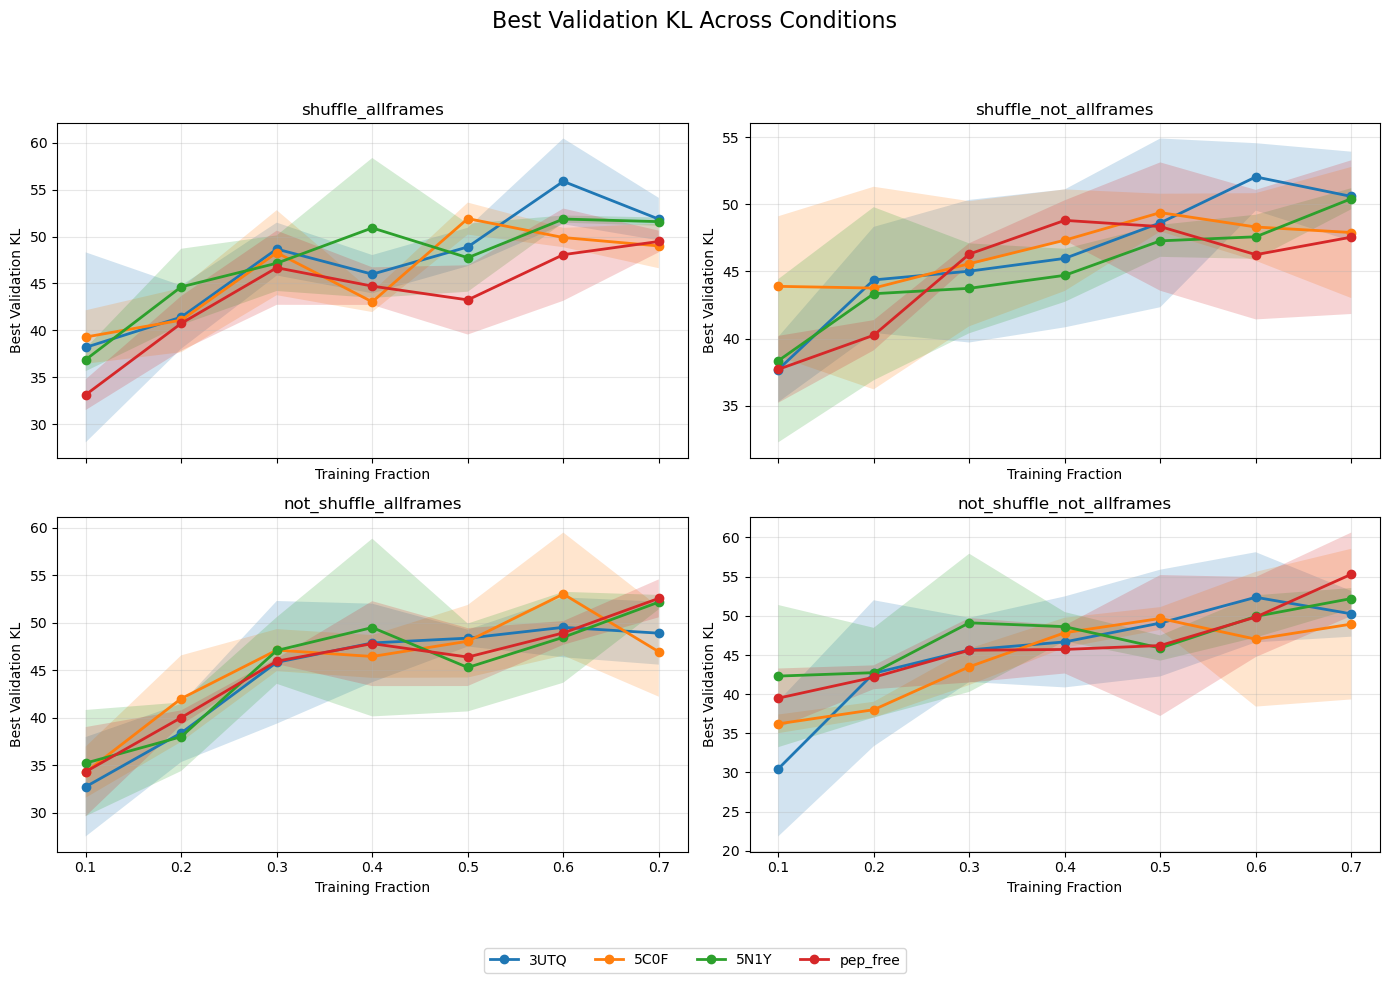

In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch

fractions = [10, 20, 30, 40, 50, 60, 70]
proteins = ["3UTQ", "5C0F", "5N1Y", "pep_free"]
replicas = [0, 1, 2]

conditions = [
    "shuffle_allframes",
    "shuffle_not_allframes",
    "not_shuffle_allframes",
    "not_shuffle_not_allframes"
]

base_root = "../Equal_frames"
fractions_float = [f / 100 for f in fractions]

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=False)
axes = axes.flatten()

for ax, condition in zip(axes, conditions):

    protein_means = {}
    protein_stds = {}

    for protein in proteins:

        rep_kl_all = []

        for rep in replicas:

            rep_dir = os.path.join(
                base_root,
                condition,
                protein,
                f"{protein}_rep_{rep}"
            )

            rep_kl = []

            for frac in fractions:

                ckpt_path = os.path.join(
                    rep_dir,
                    f"fraction_{frac}",
                    "best.ckpt"
                )

                if not os.path.exists(ckpt_path):
                    print(f"[WARNING] Missing checkpoint: {ckpt_path}")
                    rep_kl.append(np.nan)
                    continue

                ckpt = torch.load(ckpt_path, map_location="cpu")
                rep_kl.append(ckpt["best_val_kl"])

            rep_kl_all.append(rep_kl)

        rep_kl_all = np.array(rep_kl_all, dtype=float)

        protein_means[protein] = np.nanmean(rep_kl_all, axis=0)
        protein_stds[protein] = np.nanstd(rep_kl_all, axis=0)

    for protein in proteins:

        mean_vals = protein_means[protein]
        std_vals = protein_stds[protein]

        ax.plot(
            fractions_float,
            mean_vals,
            marker="o",
            linewidth=2,
            label=protein
        )

        ax.fill_between(
            fractions_float,
            mean_vals - std_vals,
            mean_vals + std_vals,
            alpha=0.2
        )

    ax.set_title(condition)
    ax.set_xlabel("Training Fraction")
    ax.set_ylabel("Best Validation KL")
    ax.grid(True, alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=4,
    frameon=True,
    bbox_to_anchor=(0.5, 0.01)
)

fig.suptitle(
    "Best Validation KL Across Conditions",
    fontsize=16,
    y=0.98
)

plt.tight_layout(rect=[0, 0.08, 1, 0.94])

plt.savefig(
    "../Equal_frames/BestValKL_all_conditions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()